# Autoencoders and Latent Space: Studying their power for data compression

Medium Article explaining the study: [Medium Article](https://medium.com/@mathparracho/autoencoders-and-latent-space-studying-their-power-for-data-compression-7f6b59d9694b)

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.models import Model
from keras.layers import Dense, Input
from keras.optimizers import Adam

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
# Load and preprocess the MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten the data
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

11490434/11490434 [==============================] - 1s 0us/step


## Defining the 2D Latent-Space Autoencoder

In [7]:
# Define a Stacked Autoencoder model
coder = Sequential()
decoder = Sequential()

# Encoder
coder.add(Dense(128, input_shape=(784,), activation='relu'))
coder.add(Dense(64, activation='relu'))
coder.add(Dense(2, activation='relu'))## Latent Space of dim2.

# Decoder
decoder.add(Dense(64, activation='relu'))
decoder.add(Dense(128, activation='relu'))
decoder.add(Dense(784, activation='sigmoid'))

# Shape for the coder input layer
input_layer = Input(shape=(784,))

# Shape for the coder output layer
encoded = coder(input_layer)

# Shape for the decoder output layer
decoded = decoder(encoded)

# Complete Model
autoencoder = Model(inputs=input_layer, outputs=decoded)

Epoch 1/10
469/469 [==============================] - 5s 8ms/step - loss: 0.0730 - val_loss: 0.0556
Epoch 2/10
469/469 [==============================] - 4s 8ms/step - loss: 0.0530 - val_loss: 0.0513
Epoch 3/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0499 - val_loss: 0.0480
Epoch 4/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0465 - val_loss: 0.0454
Epoch 5/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0446 - val_loss: 0.0440
Epoch 6/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0435 - val_loss: 0.0430
Epoch 7/10
469/469 [==============================] - 4s 7ms/step - loss: 0.0426 - val_loss: 0.0426
Epoch 8/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0420 - val_loss: 0.0419
Epoch 9/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0415 - val_loss: 0.0416
Epoch 10/10
313/313 [==============================] - 1s 2ms/step


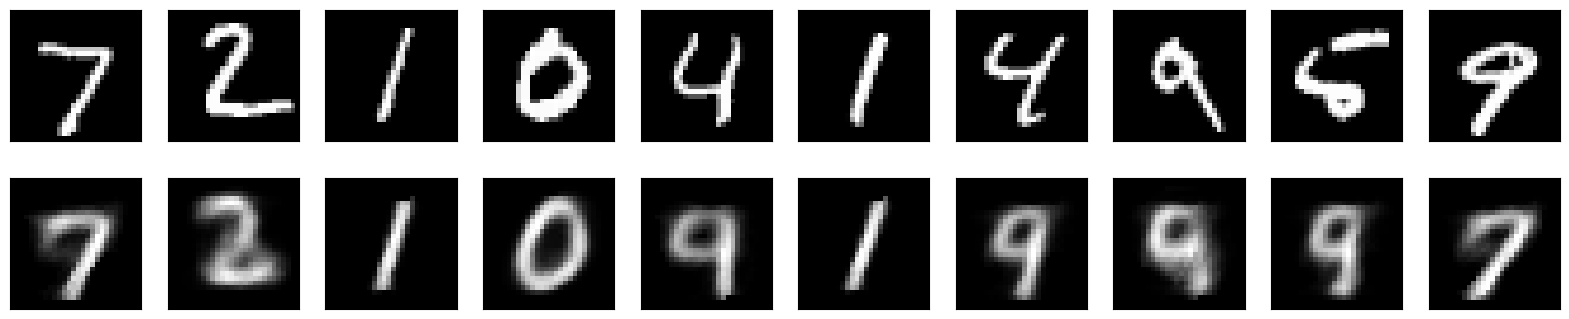

In [8]:
# Compile the model
coder.compile(optimizer=Adam(), loss='mean_squared_error')
decoder.compile(optimizer=Adam(), loss='mean_squared_error')
autoencoder.compile(optimizer=Adam(), loss='mean_squared_error')

# Train the autoencoder
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# Plot the original and reconstructed images
outputImages = autoencoder.predict(x_test)

n = 10  # Number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original Images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed Images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(outputImages[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

313/313 [==============================] - 1s 2ms/step


/tmp/ipykernel_47/4257001790.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(x=encondedImages[:,0], y=encondedImages[:,1], s=2.0, cmap='tab10', alpha=0.9, zorder=2)


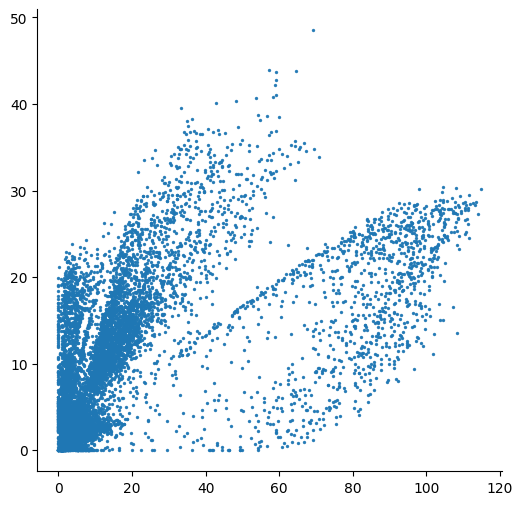

In [10]:
# Getting the latent space representation of the input images
encondedImages = coder.predict(x_test)

# Creating a scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(x=encondedImages[:,0], y=encondedImages[:,1], s=2.0, cmap='tab10', alpha=0.9, zorder=2)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

## Defining the 30D Latent-Space Autoencoder

In [11]:
# Define a Stacked Autoencoder model
coder = Sequential()
decoder = Sequential()

# Encoder
coder.add(Dense(128, input_shape=(784,), activation='relu'))
coder.add(Dense(64, activation='relu'))
coder.add(Dense(30, activation='relu'))## Latent Space of dim30.

# Decoder
decoder.add(Dense(64, activation='relu'))
decoder.add(Dense(128, activation='relu'))
decoder.add(Dense(784, activation='sigmoid'))

# Shape for the coder input layer
input_layer = Input(shape=(784,))

# Shape for the coder output layer
encoded = coder(input_layer)

# Shape for the decoder output layer
decoded = decoder(encoded)

# Complete Model
autoencoder = Model(inputs=input_layer, outputs=decoded)

Epoch 1/10
469/469 [==============================] - 5s 8ms/step - loss: 0.0474 - val_loss: 0.0261
Epoch 2/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0231 - val_loss: 0.0204
Epoch 3/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0191 - val_loss: 0.0173
Epoch 4/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0166 - val_loss: 0.0153
Epoch 5/10
469/469 [==============================] - 4s 8ms/step - loss: 0.0153 - val_loss: 0.0146
Epoch 6/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0145 - val_loss: 0.0138
Epoch 7/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0137 - val_loss: 0.0131
Epoch 8/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0130 - val_loss: 0.0124
Epoch 9/10
469/469 [==============================] - 3s 7ms/step - loss: 0.0125 - val_loss: 0.0119
Epoch 10/10
313/313 [==============================] - 1s 2ms/step


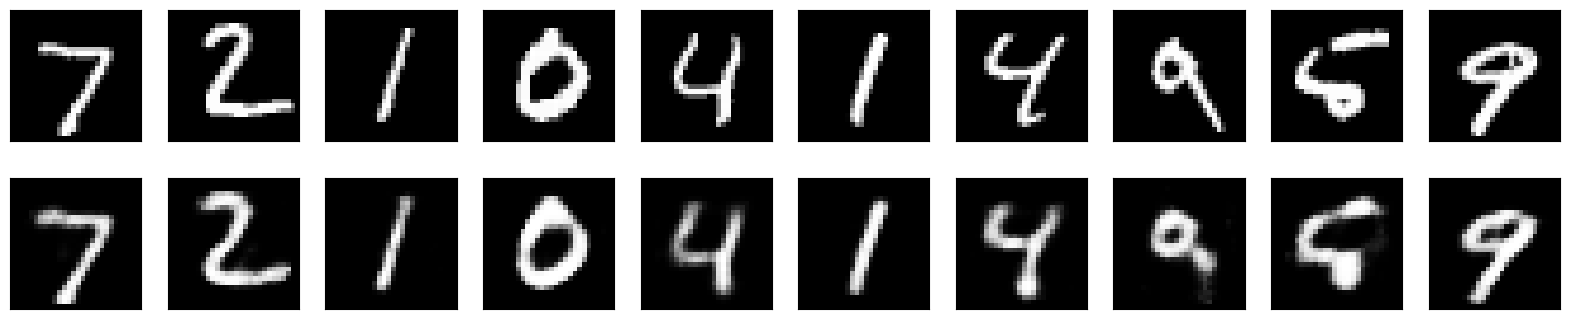

In [12]:
# Compile the model
coder.compile(optimizer=Adam(), loss='mean_squared_error')
decoder.compile(optimizer=Adam(), loss='mean_squared_error')
autoencoder.compile(optimizer=Adam(), loss='mean_squared_error')

# Train the autoencoder
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# Plot the original and reconstructed images
outputImages = autoencoder.predict(x_test)

n = 10  # Number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original Images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed Images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(outputImages[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()